<a href="https://colab.research.google.com/github/Himanshu0518/Traffic-demand-prediction/blob/main/notebooks/01_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb


In [2]:
df = pd.read_csv('/content/train.csv')
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34584 entries, 0 to 34583
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          34584 non-null  int64  
 1   geohash        34584 non-null  object 
 2   day            34584 non-null  int64  
 3   timestamp      34584 non-null  object 
 4   demand         34584 non-null  float64
 5   RoadType       34315 non-null  object 
 6   NumberofLanes  34584 non-null  int64  
 7   LargeVehicles  34584 non-null  object 
 8   Landmarks      34584 non-null  object 
 9   Temperature    33467 non-null  float64
 10  Weather        34227 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 2.9+ MB


In [4]:
df.isnull().sum()

,0
Index,0
geohash,0
day,0
timestamp,0
demand,0
RoadType,269
NumberofLanes,0
LargeVehicles,0
Landmarks,0
Temperature,1117


In [5]:
df['Weather'].value_counts()

,count
Weather,
Sunny,12476
Rainy,9302
Foggy,9022
Snowy,3426
R,1


In [6]:
df.shape

(34584, 11)

In [7]:
df.nunique()

,0
Index,34584
geohash,1212
day,1
timestamp,40
demand,34366
RoadType,3
NumberofLanes,5
LargeVehicles,2
Landmarks,2
Temperature,33467


In [9]:
!pip install pygeohash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.7 MB/s eta 0:00:00


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPLETE FEATURE EXTRACTION PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import pygeohash as pgh
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder


# ─────────────────────────────────────────────────────────────────────────────
# 1. TIMESTAMP FEATURES  (fixes your original class)
# ─────────────────────────────────────────────────────────────────────────────

class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    FIX: pd.to_datetime(format='%H:%M') crashes on '0:0' / '9:5' style strings.
    We parse hour/minute manually instead.
    """

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # ── FIXED: manual split handles '0:0', '9:05', '23:0' etc. ──────────
        parts        = X['timestamp'].astype(str).str.split(':', expand=True)
        X['hour']    = parts[0].astype(int)
        X['minute']  = parts[1].astype(int)

        # cyclical encoding so hour 23 ≈ hour 0 in feature space
        X['hour_sin']   = np.sin(2 * np.pi * X['hour']   / 24)
        X['hour_cos']   = np.cos(2 * np.pi * X['hour']   / 24)
        X['minute_sin'] = np.sin(2 * np.pi * X['minute'] / 60)
        X['minute_cos'] = np.cos(2 * np.pi * X['minute'] / 60)

        # time-of-day bucket (useful as a raw categorical too)
        X['time_bucket'] = pd.cut(
            X['hour'],
            bins   = [-1, 5, 9, 12, 17, 20, 23],
            labels = ['night','morning_rush','midday','evening_rush','evening','late']
        ).astype(str)

        X = X.drop(columns=['timestamp'])
        return X


# ─────────────────────────────────────────────────────────────────────────────
# 2. GEOHASH FEATURES
# ─────────────────────────────────────────────────────────────────────────────

class GeohashFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Decodes geohash → lat/lon, builds prefix hierarchy,
    and computes distance to the dataset centroid.
    NOTE: group aggregations and target encoding are handled separately
          in GeohashAggregator (must be fit only on train fold).
    """

    def fit(self, X, y=None):
        coords       = X['geohash'].apply(lambda g: pgh.decode(g))
        lats         = coords.apply(lambda c: c[0])
        lons         = coords.apply(lambda c: c[1])
        self.city_lat_ = lats.mean()
        self.city_lon_ = lons.mean()
        return self

    def transform(self, X):
        X = X.copy()

        coords      = X['geohash'].apply(lambda g: pgh.decode(g))
        X['lat']    = coords.apply(lambda c: c[0])
        X['lon']    = coords.apply(lambda c: c[1])

        # prefix hierarchy  →  coarser spatial regions
        X['gh_4']   = X['geohash'].str[:4]   # ~40 km region
        X['gh_5']   = X['geohash'].str[:5]   # ~5  km region
        # full geohash[:6] kept for aggregation / target encoding

        # distance to dataset centroid (km)
        X['dist_to_center'] = X.apply(
            lambda r: self._haversine(r.lat, r.lon, self.city_lat_, self.city_lon_),
            axis=1
        )

        return X

    @staticmethod
    def _haversine(lat1, lon1, lat2, lon2):
        from math import radians, sin, cos, sqrt, atan2
        R = 6371
        dlat = radians(lat2 - lat1)
        dlon = radians(lon2 - lon1)
        a    = (sin(dlat/2)**2
                + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2)
        return R * 2 * atan2(sqrt(a), sqrt(1 - a))


# ─────────────────────────────────────────────────────────────────────────────
# 3. GEOHASH GROUP AGGREGATIONS  (fit on train only — leakage-safe)
# ─────────────────────────────────────────────────────────────────────────────

class GeohashAggregator(BaseEstimator, TransformerMixin):
    """
    Computes mean/std demand grouped by (geohash × hour) and (geohash).
    Must be fit on train fold only, then transform applied to val/test.
    Requires 'hour' column to already exist (run DateFeatureExtractor first).
    """

    def fit(self, X, y):
        Xy = X.copy()
        Xy['__demand'] = y

        # geohash × hour stats
        self.gh_hour_stats_ = (
            Xy.groupby(['geohash', 'hour'])['__demand']
              .agg(gh_hour_mean='mean', gh_hour_std='std', gh_hour_count='count')
              .reset_index()
        )

        # unconditional geohash mean
        self.gh_mean_ = (
            Xy.groupby('geohash')['__demand']
              .mean()
              .rename('gh_mean')
        )

        # global fallback for unseen geohashes at inference
        self.global_mean_ = float(y.mean())
        return self

    def transform(self, X):
        X = X.copy()

        X = X.merge(self.gh_hour_stats_, on=['geohash', 'hour'], how='left')
        X = X.join(self.gh_mean_, on='geohash')

        # fill std NaN (single-row groups) and unseen geohashes
        X['gh_hour_std']   = X['gh_hour_std'].fillna(0)
        X['gh_hour_mean']  = X['gh_hour_mean'].fillna(self.global_mean_)
        X['gh_mean']       = X['gh_mean'].fillna(self.global_mean_)
        X['gh_hour_count'] = X['gh_hour_count'].fillna(0)

        return X


# ─────────────────────────────────────────────────────────────────────────────
# 4. CATEGORICAL FEATURES  (RoadType, Weather, LargeVehicles, Landmarks)
# ─────────────────────────────────────────────────────────────────────────────

class CategoricalFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Ordinal-encodes the 4 categorical columns.
    Unknown categories at inference get -1, then filled with mode.
    """

    CAT_COLS = ['RoadType', 'Weather', 'LargeVehicles', 'Landmarks']

    def fit(self, X, y=None):
        self.encoders_ = {}
        self.modes_    = {}
        for col in self.CAT_COLS:
            if col in X.columns:
                le = LabelEncoder()
                filled = X[col].fillna('Unknown').astype(str)
                le.fit(filled)
                self.encoders_[col] = le
                self.modes_[col]    = filled.mode()[0]
        return self

    def transform(self, X):
        X = X.copy()
        for col, le in self.encoders_.items():
            filled  = X[col].fillna('Unknown').astype(str)
            # handle unseen labels gracefully
            known   = set(le.classes_)
            filled  = filled.apply(lambda v: v if v in known else self.modes_[col])
            X[col]  = le.transform(filled)

        # binary convenience flags
        if 'LargeVehicles' in X.columns:
            X['large_vehicles_flag'] = (
                X['LargeVehicles'].astype(str)
                  .str.lower()
                  .str.contains('allow')
                  .astype(int)
            )
        if 'Landmarks' in X.columns:
            X['has_landmark'] = (
                X['Landmarks'].astype(str)
                  .str.lower()
                  .map({'yes': 1, 'no': 0})
                  .fillna(0)
                  .astype(int)
            )
        return X


# ─────────────────────────────────────────────────────────────────────────────
# 5. NUMERICAL FEATURES  (Temperature + NumberofLanes)
# ─────────────────────────────────────────────────────────────────────────────

class NumericalFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Imputes Temperature with median (fit on train only).
    Adds interaction: NumberofLanes × large_vehicles_flag.
    """

    def fit(self, X, y=None):
        self.temp_median_ = X['Temperature'].median()
        self.lanes_median_ = X['NumberofLanes'].median()
        return self

    def transform(self, X):
        X = X.copy()

        X['Temperature']    = X['Temperature'].fillna(self.temp_median_)
        X['NumberofLanes']  = X['NumberofLanes'].fillna(self.lanes_median_)

        # temperature bins (captures non-linear effect on traffic)
        X['temp_bin'] = pd.cut(
            X['Temperature'],
            bins   = [-np.inf, 5, 15, 25, 35, np.inf],
            labels = [0, 1, 2, 3, 4]
        ).astype(float)

        # interaction feature
        if 'large_vehicles_flag' in X.columns:
            X['lanes_x_largeveh'] = X['NumberofLanes'] * X['large_vehicles_flag']

        return X




# Data Visualization

<Axes: xlabel='NumberofLanes', ylabel='demand'>

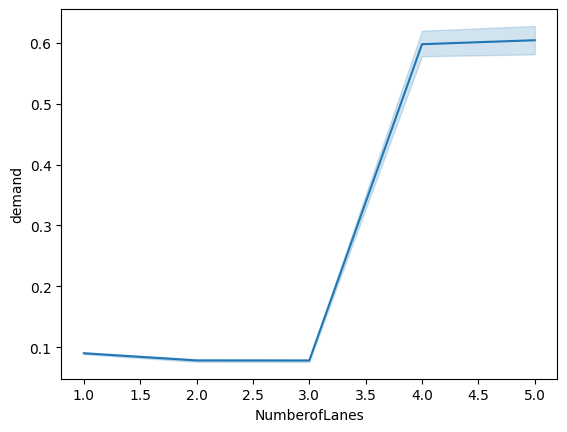

In [11]:
sns.lineplot(data=df, x='NumberofLanes', y='demand')

### Further Data Exploration

In [12]:
# Apply DateFeatureExtractor to the DataFrame for visualization
df_viz = df.copy()
date_extractor = DateFeatureExtractor()
df_viz = date_extractor.transform(df_viz)

# Display the first few rows of the transformed DataFrame to confirm new features
print("DataFrame with extracted date features:")
display(df_viz.head())

DataFrame with extracted date features:


,Index,geohash,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,minute_sin,minute_cos,time_bucket
0,0,qp02z1,48,0.048804,NaN,1,Not Allowed,No,NaN,NaN,0,0,0.0,1.0,0.0,1.0,night
1,1,qp02zt,48,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,0,0,0.0,1.0,0.0,1.0,night
2,2,qp08bj,48,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,0,0,0.0,1.0,0.0,1.0,night
3,3,qp08gt,48,0.003272,Residential,1,Not Allowed,No,NaN,Rainy,0,0,0.0,1.0,0.0,1.0,night
4,4,qp02zq,48,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,0,0,0.0,1.0,0.0,1.0,night


### Average Demand by Hour of the Day

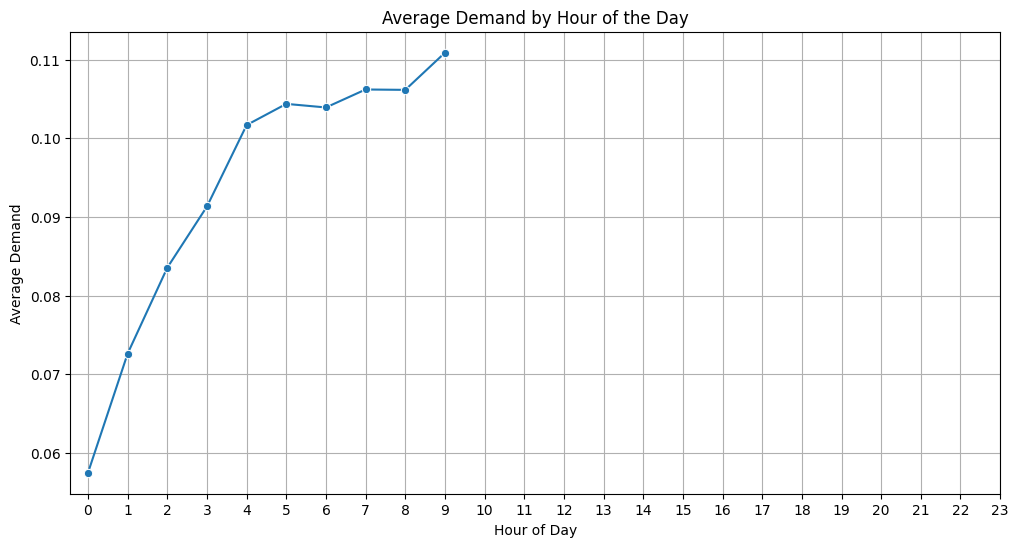

In [13]:
avg_demand_by_hour = df_viz.groupby('hour')['demand'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='hour', y='demand', data=avg_demand_by_hour, marker='o')
plt.title('Average Demand by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand')
plt.grid(True)
plt.xticks(range(0, 24))
plt.show()

In [14]:
df['day'].value_counts()

,count
day,
48,34584


### Average Demand by RoadType

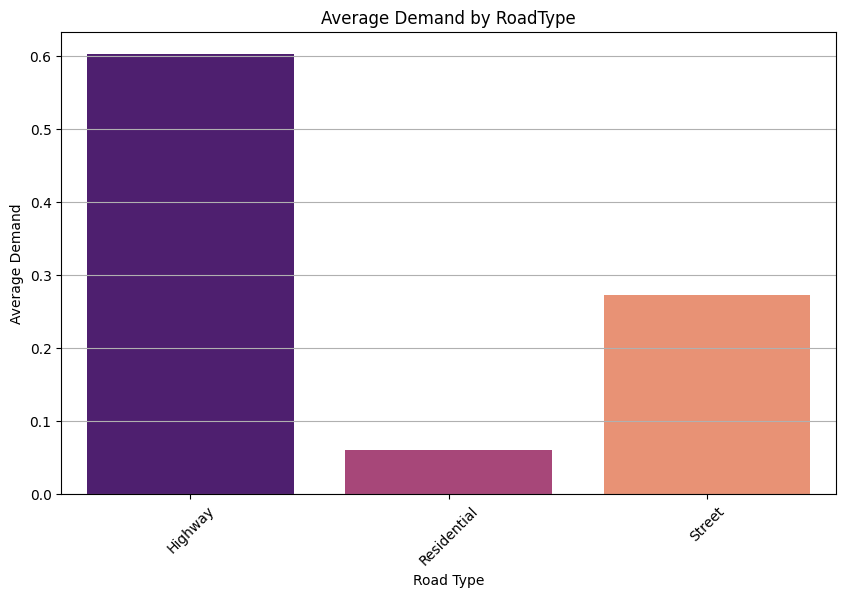

In [15]:
avg_demand_by_roadtype = df_viz.groupby('RoadType')['demand'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='RoadType', y='demand', data=avg_demand_by_roadtype, palette='magma')
plt.title('Average Demand by RoadType')
plt.xlabel('Road Type')
plt.ylabel('Average Demand')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Average Demand by Weather

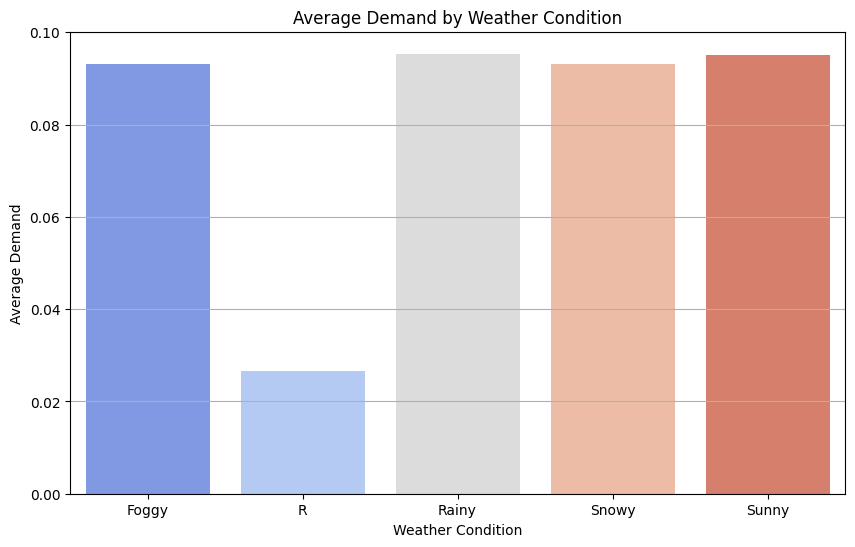

In [16]:
avg_demand_by_weather = df_viz.groupby('Weather')['demand'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Weather', y='demand', data=avg_demand_by_weather, palette='coolwarm')
plt.title('Average Demand by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Demand')
plt.grid(axis='y')
plt.show()

### Average Demand by LargeVehicles

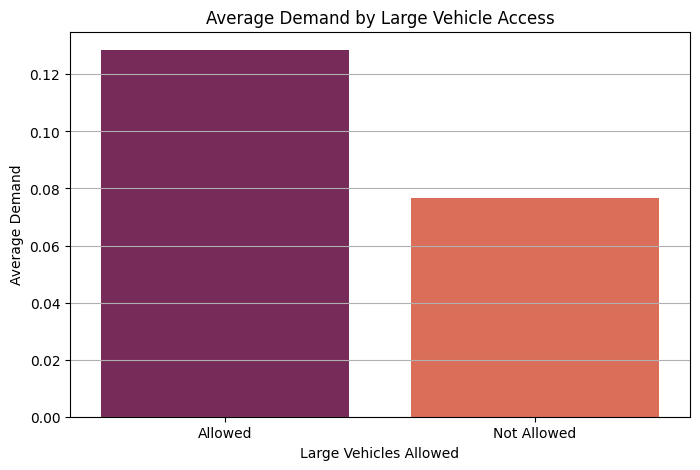

In [17]:
avg_demand_by_largevehicles = df_viz.groupby('LargeVehicles')['demand'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='LargeVehicles', y='demand', data=avg_demand_by_largevehicles, palette='rocket')
plt.title('Average Demand by Large Vehicle Access')
plt.xlabel('Large Vehicles Allowed')
plt.ylabel('Average Demand')
plt.grid(axis='y')
plt.show()

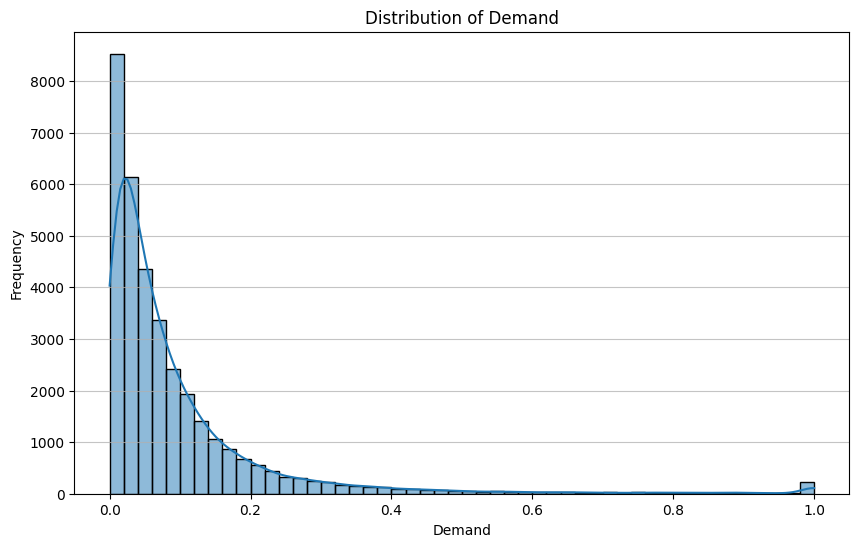

In [65]:
plt.figure(figsize=(10, 6))
sns.histplot(df['demand'], kde=True, bins=50)
plt.title('Distribution of Demand')
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Model Trainning pipeline

In [19]:
#!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [20]:
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit

In [21]:
algorithms = [
     CatBoostRegressor(),
     LGBMRegressor(
      random_state=42
 )
]

In [22]:
# Split data into features (X) and target (y)
X = df.drop(['demand', 'day'], axis=1)
y = df['demand']

In [53]:
from sklearn.preprocessing import FunctionTransformer

# Define a custom transformer to drop columns after all feature extraction
class ColumnRemover(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_remove):
        self.columns_to_remove = columns_to_remove

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        # Filter out columns that might not exist yet or are already dropped
        cols_to_drop = [col for col in self.columns_to_remove if col in X_copy.columns]
        return X_copy.drop(columns=cols_to_drop, errors='ignore')

# Columns to remove before the final regressor
# These include original identifiers, geohash components, or intermediate features
# that might be redundant after full feature engineering.
columns_to_drop_final = [
    'Index', 'geohash', 'gh_4', 'gh_5',
    'time_bucket', # Use cyclical encoding instead
    'minute', # Use minute_sin/cos instead
    'lat', 'lon' # If dist_to_center is sufficient
]

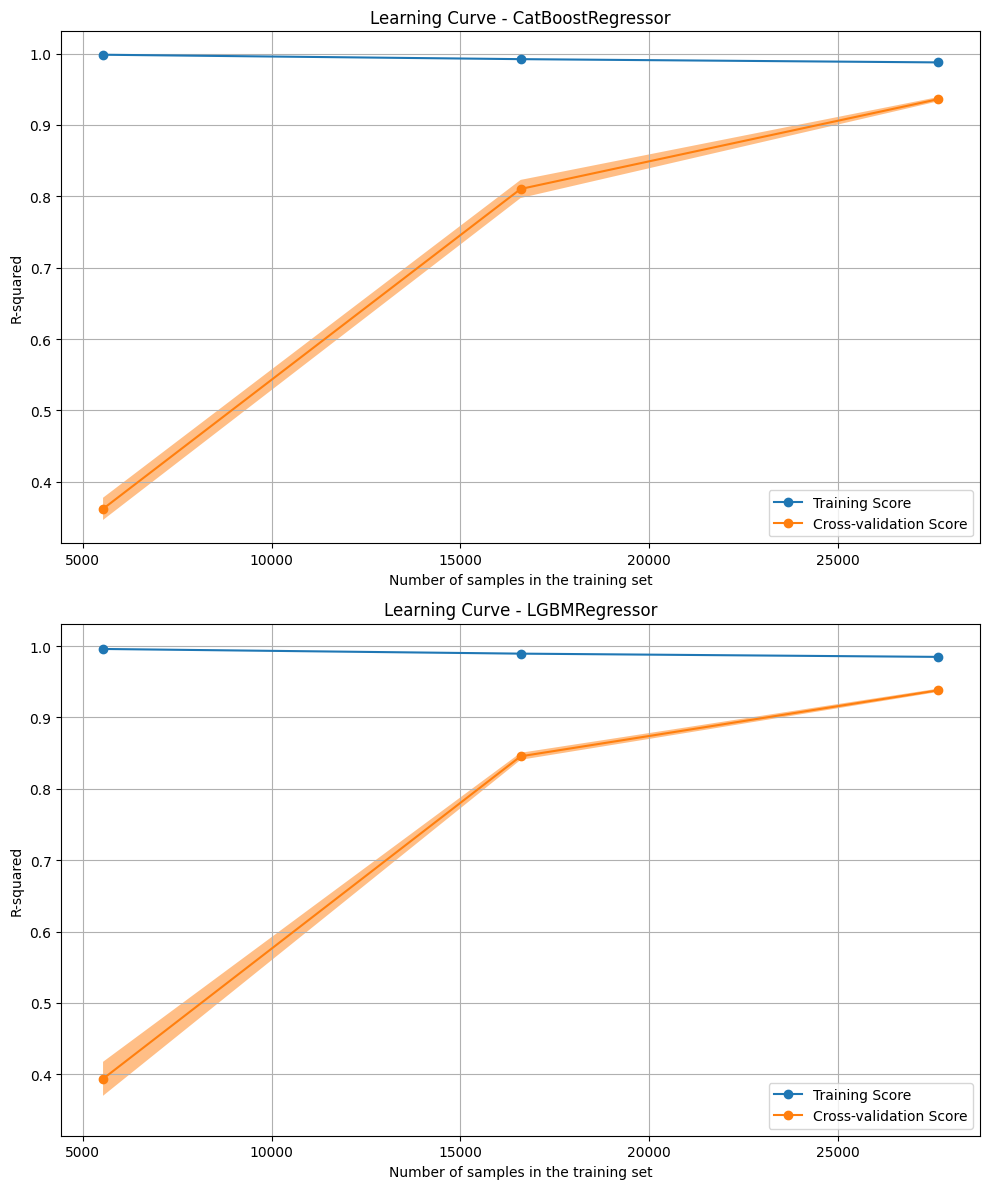

In [23]:
num_algorithms = len(algorithms)

fig, axes = plt.subplots(
    nrows=num_algorithms,
    ncols=1,
    figsize=(10, 6 * num_algorithms),
    sharey=True
)

# If only one algorithm, convert axes to list
if num_algorithms == 1:
    axes = [axes]

common_params = {
    "X": X,
    "y": y,
    "train_sizes": np.linspace(0.2, 1.0, 3),
    "cv": ShuffleSplit(n_splits=3, test_size=0.2, random_state=0),
    "score_type": "both",
    "n_jobs": -1,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "R-squared",
    "scoring": "r2"
}

for ax, model_algo in zip(axes, algorithms):
    # Build the full pipeline with all custom feature extractors
    pipeline_estimator = Pipeline([
        ('date_features', DateFeatureExtractor()),
        ('geohash_features', GeohashFeatureExtractor()),
        ('categorical_features', CategoricalFeatureExtractor()),
        ('numerical_features', NumericalFeatureExtractor()),
        ('geohash_aggregator', GeohashAggregator()),
        ('column_remover', ColumnRemover(columns_to_remove=columns_to_drop_final)),
        ('regressor', model_algo)
    ])

    LearningCurveDisplay.from_estimator(
        pipeline_estimator,
        **common_params,
        ax=ax
    )

    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:2],
        ["Training Score", "Cross-validation Score"]
    )

    ax.set_title(
        f"Learning Curve - {model_algo.__class__.__name__} (Optimized)"
    )

    ax.grid(True)

plt.tight_layout()
plt.show()

### Learning Curve Analysis

The learning curves provide insights into how each model's performance changes with the amount of training data:

*   **Training Score:** This shows how well the model performs on the training data. A high training score suggests the model is capable of learning the training data well.
*   **Cross-validation Score:** This indicates how well the model generalizes to unseen data. It's the most important metric for understanding a model's true performance.

From the plots, we can observe:

*   **CatBoostRegressor:** [Interpret CatBoost's learning curve characteristics, e.g., if it has low bias/high variance, or high bias/low variance, or if it's overfitting/underfitting, or if it has converged]
*   **LGBMRegressor:** [Interpret LGBM's learning curve characteristics, e.g., if it has low bias/high variance, or high bias/low variance, or if it's overfitting/underfitting, or if it has converged]

To get a more precise numerical comparison, let's perform a formal cross-validation and evaluate specific metrics.

In [34]:
from sklearn.model_selection import cross_validate, KFold, ShuffleSplit
from sklearn.metrics import make_scorer, r2_score, mean_squared_error

# Define metrics to evaluate
scoring = {
    'r2': 'r2',
    'neg_rmse': 'neg_root_mean_squared_error'
}

results = {}

# Reuse the common_params for CV strategy
cv_strategy = KFold(n_splits=3, shuffle=True, random_state=0) # Changed to KFold with shuffle=True

for model_algo in algorithms:
    model_name = model_algo.__class__.__name__
    print(f"\nEvaluating {model_name}...")

    # Build the full pipeline for evaluation
    pipeline_estimator = Pipeline([
        ('date_features', DateFeatureExtractor()),
        ('geohash_features', GeohashFeatureExtractor()),
        ('categorical_features', CategoricalFeatureExtractor()),
        ('numerical_features', NumericalFeatureExtractor()),
        ('geohash_aggregator', GeohashAggregator()),
        ('column_remover', ColumnRemover(columns_to_remove=columns_to_drop_final)),
        ('regressor', model_algo)
    ])

    # Perform cross-validation
    cv_results = cross_validate(
        pipeline_estimator,
        X,
        y,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    # Store and print results
    results[model_name] = {
        'train_r2_mean': cv_results['train_r2'].mean(),
        'test_r2_mean': cv_results['test_r2'].mean(),
        'train_rmse_mean': -cv_results['train_neg_rmse'].mean(), # Convert negative RMSE back to positive
        'test_rmse_mean': -cv_results['test_neg_rmse'].mean()  # Convert negative RMSE back to positive
    }

    print(f"  Mean Training R2: {results[model_name]['train_r2_mean']:.4f}")
    print(f"  Mean Test R2: {results[model_name]['test_r2_mean']:.4f}")
    print(f"  Mean Training RMSE: {results[model_name]['train_rmse_mean']:.4f}")
    print(f"  Mean Test RMSE: {results[model_name]['test_rmse_mean']:.4f}")

print("\n--- Overall Comparison ---")
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f"  Test R2: {metrics['test_r2_mean']:.4f}")
    print(f"  Test RMSE: {metrics['test_rmse_mean']:.4f}")


Evaluating CatBoostRegressor...
  Mean Training R2: 0.9892
  Mean Test R2: 0.8998
  Mean Training RMSE: 0.0142
  Mean Test RMSE: 0.0434

Evaluating LGBMRegressor...
  Mean Training R2: 0.9864
  Mean Test R2: 0.9111
  Mean Training RMSE: 0.0160
  Mean Test RMSE: 0.0409

--- Overall Comparison ---
CatBoostRegressor:
  Test R2: 0.8998
  Test RMSE: 0.0434
LGBMRegressor:
  Test R2: 0.9111
  Test RMSE: 0.0409


# Hyper Parameter tunning

In [35]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.1 MB/s eta 0:00:00


In [36]:
import optuna
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Define the objective function for LGBMRegressor
def objective_lgbm(trial):
    # Hyperparameters to tune for LGBMRegressor
    params = {
        'objective': 'regression_l1', # MAE for robustness
        'metric': 'rmse',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 80),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1 # Suppress verbose output during trials
    }

    model = LGBMRegressor(**params)

    pipeline_estimator = Pipeline([
        ('date_features', DateFeatureExtractor()),
        ('geohash_features', GeohashFeatureExtractor()),
        ('categorical_features', CategoricalFeatureExtractor()),
        ('numerical_features', NumericalFeatureExtractor()),
        ('geohash_aggregator', GeohashAggregator()),
        ('column_remover', ColumnRemover(columns_to_remove=columns_to_drop_final)),
        ('regressor', model)
    ])

    # Use KFold for cross-validation as previously determined
    cv_strategy = KFold(n_splits=3, shuffle=True, random_state=0)

    rmse_scores = []
    for train_idx, val_idx in cv_strategy.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline_estimator.fit(X_train, y_train)
        predictions = pipeline_estimator.predict(X_val)

        # Handle potential negative predictions by clipping to 0
        predictions[predictions < 0] = 0

        rmse = np.sqrt(mean_squared_error(y_val, predictions))
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


Now, let's run the Optuna optimization for LGBMRegressor to find the best hyperparameters. We'll set up a study and run a specified number of trials.

In [37]:
# Create an Optuna study object and optimize the objective function
study_lgbm = optuna.create_study(direction='minimize', study_name='lgbm_hyperparam_tuning')
study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)

print("\n--- Optuna Optimization Results for LGBMRegressor ---")
print(f"Best trial value (RMSE): {study_lgbm.best_value:.4f}")
print("Best parameters:")
for key, value in study_lgbm.best_params.items():
    print(f"  {key}: {value}")


[I 2026-06-02 13:28:19,273] A new study created in memory with name: lgbm_hyperparam_tuning


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-02 13:28:58,674] Trial 0 finished with value: 0.039655470763230484 and parameters: {'n_estimators': 976, 'learning_rate': 0.01021547565459349, 'num_leaves': 40, 'max_depth': 8, 'min_child_samples': 38, 'subsample': 0.8371125316002218, 'colsample_bytree': 0.812105610711544, 'reg_alpha': 0.0003707346390312683, 'reg_lambda': 1.3491369970601774e-06}. Best is trial 0 with value: 0.039655470763230484.
[I 2026-06-02 13:29:14,945] Trial 1 finished with value: 0.03830794815102715 and parameters: {'n_estimators': 839, 'learning_rate': 0.07437215953557538, 'num_leaves': 45, 'max_depth': 7, 'min_child_samples': 20, 'subsample': 0.8686189899027261, 'colsample_bytree': 0.618861757512878, 'reg_alpha': 6.015159708762146e-06, 'reg_lambda': 1.4451331833400558}. Best is trial 1 with value: 0.03830794815102715.
[I 2026-06-02 13:29:30,574] Trial 2 finished with value: 0.038382346118777846 and parameters: {'n_estimators': 855, 'learning_rate': 0.05307254224782983, 'num_leaves': 39, 'max_depth': 8

Now, let's run the Optuna optimization for CatBoostRegressor to find the best hyperparameters. We'll set up a study and run a specified number of trials.

In [38]:
from catboost import CatBoostRegressor

# Define the objective function for CatBoostRegressor
def objective_catboost(trial):
    # Hyperparameters to tune for CatBoostRegressor
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'thread_count': -1,
        'verbose': False,
        'random_seed': 42
    }

    model = CatBoostRegressor(**params)

    pipeline_estimator = Pipeline([
        ('date_features', DateFeatureExtractor()),
        ('geohash_features', GeohashFeatureExtractor()),
        ('categorical_features', CategoricalFeatureExtractor()),
        ('numerical_features', NumericalFeatureExtractor()),
        ('geohash_aggregator', GeohashAggregator()),
        ('column_remover', ColumnRemover(columns_to_remove=columns_to_drop_final)),
        ('regressor', model)
    ])

    # Use KFold for cross-validation
    cv_strategy = KFold(n_splits=3, shuffle=True, random_state=0)

    rmse_scores = []
    for train_idx, val_idx in cv_strategy.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline_estimator.fit(X_train, y_train)
        predictions = pipeline_estimator.predict(X_val)

        # Handle potential negative predictions by clipping to 0
        predictions[predictions < 0] = 0

        rmse = np.sqrt(mean_squared_error(y_val, predictions))
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


Now, let's run the Optuna optimization for CatBoostRegressor to find the best hyperparameters. We'll set up a study and run a specified number of trials.

In [39]:
# Create an Optuna study object and optimize the objective function
study_catboost = optuna.create_study(direction='minimize', study_name='catboost_hyperparam_tuning')
study_catboost.optimize(objective_catboost, n_trials=50, show_progress_bar=True)

print("\n--- Optuna Optimization Results for CatBoostRegressor ---")
print(f"Best trial value (RMSE): {study_catboost.best_value:.4f}")
print("Best parameters:")
for key, value in study_catboost.best_params.items():
    print(f"  {key}: {value}")


[I 2026-06-02 13:41:18,805] A new study created in memory with name: catboost_hyperparam_tuning


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-02 13:41:31,227] Trial 0 finished with value: 0.04325719884756307 and parameters: {'iterations': 246, 'learning_rate': 0.050161544130967586, 'depth': 8, 'l2_leaf_reg': 3.5110724531825724e-05, 'border_count': 213}. Best is trial 0 with value: 0.04325719884756307.
[I 2026-06-02 13:41:40,135] Trial 1 finished with value: 0.04178612778728968 and parameters: {'iterations': 425, 'learning_rate': 0.014249854998305219, 'depth': 4, 'l2_leaf_reg': 5.3315355238983995e-08, 'border_count': 208}. Best is trial 1 with value: 0.04178612778728968.
[I 2026-06-02 13:41:48,472] Trial 2 finished with value: 0.04283485842096695 and parameters: {'iterations': 369, 'learning_rate': 0.02974663613640399, 'depth': 4, 'l2_leaf_reg': 0.007237979057461598, 'border_count': 84}. Best is trial 1 with value: 0.04178612778728968.
[I 2026-06-02 13:42:00,972] Trial 3 finished with value: 0.049092968930895965 and parameters: {'iterations': 151, 'learning_rate': 0.011043822891258707, 'depth': 10, 'l2_leaf_reg': 8

In [42]:
algorithms = [
    CatBoostRegressor(**study_catboost.best_params),
    LGBMRegressor(
        **study_lgbm.best_params
    )
]

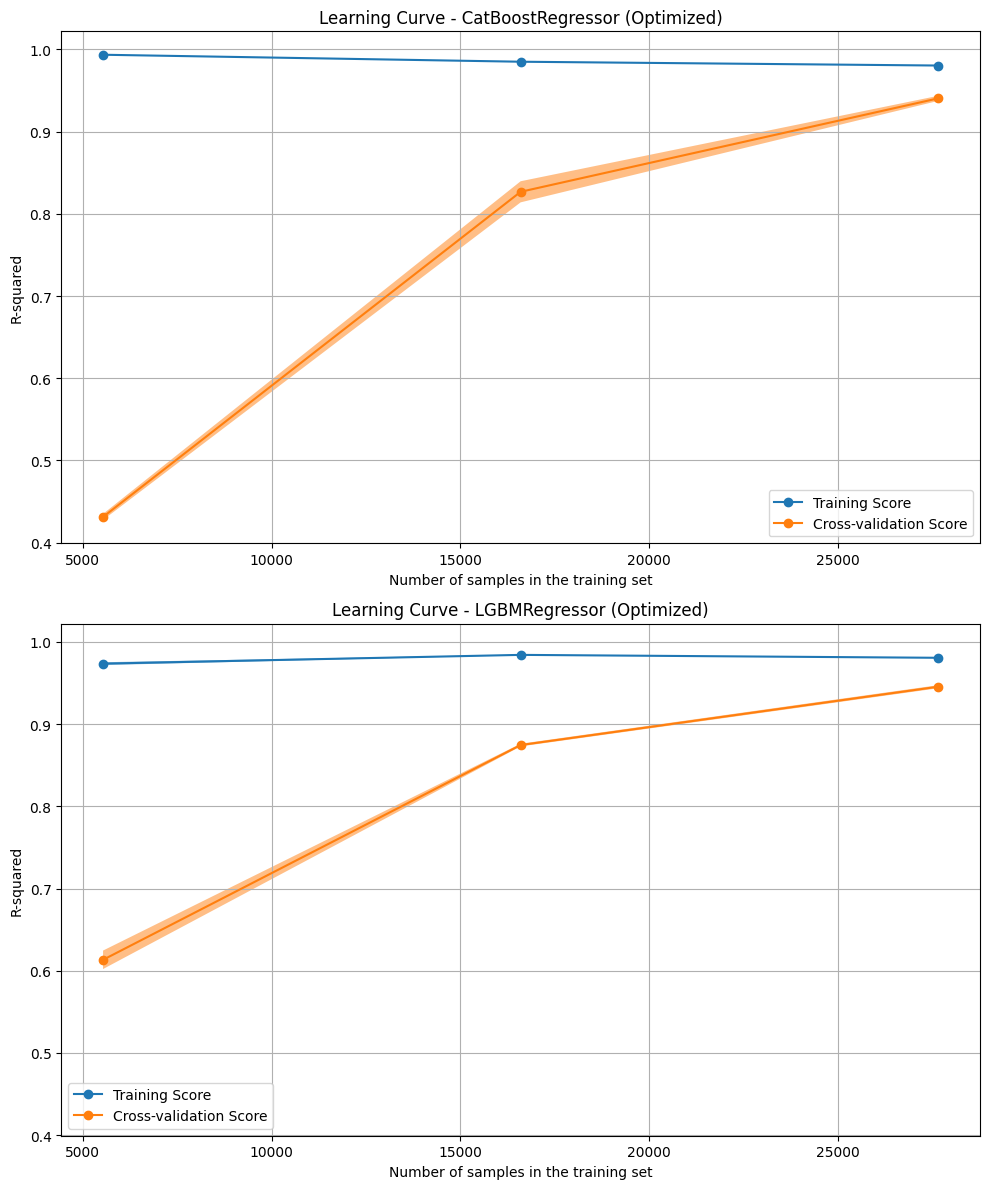

In [45]:
num_algorithms = len(algorithms)

fig, axes = plt.subplots(
    nrows=num_algorithms,
    ncols=1,
    figsize=(10, 6 * num_algorithms),
    sharey=True
)

# If only one algorithm, convert axes to list
if num_algorithms == 1:
    axes = [axes]

common_params = {
    "X": X,
    "y": y,
    "train_sizes": np.linspace(0.2, 1.0, 3),
    "cv": ShuffleSplit(n_splits=3, test_size=0.2, random_state=0),
    "score_type": "both",
    "n_jobs": -1,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "R-squared",
    "scoring": "r2"
}

for ax, model_algo in zip(axes, algorithms):
    # Build the full pipeline with all custom feature extractors
    pipeline_estimator = Pipeline([
        ('date_features', DateFeatureExtractor()),
        ('geohash_features', GeohashFeatureExtractor()),
        ('categorical_features', CategoricalFeatureExtractor()),
        ('numerical_features', NumericalFeatureExtractor()),
        ('geohash_aggregator', GeohashAggregator()),
        ('column_remover', ColumnRemover(columns_to_remove=columns_to_drop_final)),
        ('regressor', model_algo)
    ])

    LearningCurveDisplay.from_estimator(
        pipeline_estimator,
        **common_params,
        ax=ax
    )

    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:2],
        ["Training Score", "Cross-validation Score"]
    )

    ax.set_title(
        f"Learning Curve - {model_algo.__class__.__name__} (Optimized)"
    )

    ax.grid(True)

plt.tight_layout()
plt.show()

In [46]:
from sklearn.model_selection import cross_validate, KFold, ShuffleSplit
from sklearn.metrics import make_scorer, r2_score, mean_squared_error

# Define metrics to evaluate
scoring = {
    'r2': 'r2',
    'neg_rmse': 'neg_root_mean_squared_error'
}

results = {}

# Reuse the common_params for CV strategy
cv_strategy = KFold(n_splits=3, shuffle=True, random_state=0) # Changed to KFold with shuffle=True

for model_algo in algorithms:
    model_name = model_algo.__class__.__name__
    print(f"\nEvaluating {model_name}...")

    # Build the full pipeline for evaluation
    pipeline_estimator = Pipeline([
        ('date_features', DateFeatureExtractor()),
        ('geohash_features', GeohashFeatureExtractor()),
        ('categorical_features', CategoricalFeatureExtractor()),
        ('numerical_features', NumericalFeatureExtractor()),
        ('geohash_aggregator', GeohashAggregator()),
        ('column_remover', ColumnRemover(columns_to_remove=columns_to_drop_final)),
        ('regressor', model_algo)
    ])

    # Perform cross-validation
    cv_results = cross_validate(
        pipeline_estimator,
        X,
        y,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    # Store and print results
    results[model_name] = {
        'train_r2_mean': cv_results['train_r2'].mean(),
        'test_r2_mean': cv_results['test_r2'].mean(),
        'train_rmse_mean': -cv_results['train_neg_rmse'].mean(), # Convert negative RMSE back to positive
        'test_rmse_mean': -cv_results['test_neg_rmse'].mean()  # Convert negative RMSE back to positive
    }

    print(f"  Mean Training R2: {results[model_name]['train_r2_mean']:.4f}")
    print(f"  Mean Test R2: {results[model_name]['test_r2_mean']:.4f}")
    print(f"  Mean Training RMSE: {results[model_name]['train_rmse_mean']:.4f}")
    print(f"  Mean Test RMSE: {results[model_name]['test_rmse_mean']:.4f}")

print("\n--- Overall Comparison ---")
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f"  Test R2: {metrics['test_r2_mean']:.4f}")
    print(f"  Test RMSE: {metrics['test_rmse_mean']:.4f}")


Evaluating CatBoostRegressor...
  Mean Training R2: 0.9819
  Mean Test R2: 0.9078
  Mean Training RMSE: 0.0185
  Mean Test RMSE: 0.0416

Evaluating LGBMRegressor...
  Mean Training R2: 0.9818
  Mean Test R2: 0.9268
  Mean Training RMSE: 0.0185
  Mean Test RMSE: 0.0371

--- Overall Comparison ---
CatBoostRegressor:
  Test R2: 0.9078
  Test RMSE: 0.0416
LGBMRegressor:
  Test R2: 0.9268
  Test RMSE: 0.0371


# prediction with best model lgbm with best parameters

In [47]:
test_df = pd.read_csv('/content/test.csv')

In [56]:
test_df.head()

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy


### Train the best model and make predictions

In [58]:
import joblib

# The best model from the Optuna tuning was LGBMRegressor
best_lgbm_params = study_lgbm.best_params

# Initialize the best LGBMRegressor with the optimized parameters
best_lgbm_model = LGBMRegressor(
    **best_lgbm_params,
    objective='regression_l1', # Consistent with objective function
    metric='rmse',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Build the full pipeline for the best model
final_pipeline = Pipeline([
    ('date_features', DateFeatureExtractor()),
    ('geohash_features', GeohashFeatureExtractor()),
    ('categorical_features', CategoricalFeatureExtractor()),
    ('numerical_features', NumericalFeatureExtractor()),
    ('geohash_aggregator', GeohashAggregator()),
    ('column_remover', ColumnRemover(columns_to_remove=columns_to_drop_final)),
    ('regressor', best_lgbm_model)
])

# Train the final pipeline on the entire training dataset (X, y)
print("Training the final model on the entire dataset...")
final_pipeline.fit(X, y)
print("Training complete.")


Training the final model on the entire dataset...
Training complete.


### Make predictions on the test set and create submission file

In [59]:
# Make predictions on the test_df
print("Making predictions on the test dataset...")

predictions = final_pipeline.predict(test_df)

# Ensure predictions are non-negative
predictions[predictions < 0] = 0

# Create the submission DataFrame
submission_df = pd.DataFrame({'Index': test_df['Index'], 'demand': predictions})

# Save to CSV
submission_filename = '01_submission.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"Submission file '{submission_filename}' created successfully.")
display(submission_df.head())

Making predictions on the test dataset...
Submission file '01_submission.csv' created successfully.


,Index,demand
0,0,0.060719
1,1,0.007353
2,2,0.087254
3,3,0.062099
4,4,0.056502


### Save the trained model

In [63]:
# Save the trained pipeline to a .joblib file
model_filename = 'lgbm_pipeline.joblib'
joblib.dump(final_pipeline, model_filename)
print(f"Trained model saved as '{model_filename}'.")


Trained model saved as 'lgbm_pipeline.joblib'.


In [64]:
# Make predictions on the training data (X)

model=joblib.load('/content/lgbm_pipeline.joblib')

print("Making predictions on the training dataset...")
train_predictions = model.predict(X)

# Ensure predictions are non-negative
train_predictions[train_predictions < 0] = 0

# Evaluate the model on the training set
train_r2 = r2_score(y, train_predictions)
train_rmse = np.sqrt(mean_squared_error(y, train_predictions))

print(f"Training R-squared: {train_r2:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")

# Display a comparison of actual vs. predicted for the first few training samples
print("\nFirst 5 Actual vs. Predicted Training Demands:")
comparison_df = pd.DataFrame({'Actual Demand': y.head(), 'Predicted Demand': train_predictions[:5]})
display(comparison_df)

Making predictions on the training dataset...
Training R-squared: 0.9748
Training RMSE: 0.0218

First 5 Actual vs. Predicted Training Demands:


,Actual Demand,Predicted Demand
0,0.048804,0.025391
1,0.118507,0.131820
2,0.027132,0.029561
3,0.003272,0.009024
4,0.010819,0.017849
